In [2]:
pip install docx

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install python-docx pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from docx import Document
import os
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC

In [5]:
data = []
base = r"C:\Users\Admin\Downloads\P658_DATASET\Resumes"
for folder in os.listdir(base):
    folder_path = base + "\\" + folder
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".docx"):
                file_path = folder_path + "\\" + file
                doc = Document(file_path)
                text = ""
                for p in doc.paragraphs:
                    text += p.text
                data.append([text, folder])
df = pd.DataFrame(data, columns=["text", "category"])
print(df.head())

                                                text            category
0    Anubhav Kumar Singh\t\t  To work in a global...  Peoplesoft resumes
1  MuraliExperience Summary I have 6 years of exp...  Peoplesoft resumes
2  PROFILE SUMMARYI have overall 6.8 years’ exper...  Peoplesoft resumes
3   PeopleSoft AdminVARKALA VIKASCareer Objective...  Peoplesoft resumes
4  PeopleSoft Administration Vivekanand Sayana   ...  Peoplesoft resumes


In [6]:
df.tail()

,text,category
27,Rahul (Techno Functional Consultant) Profess...,workday resumes
28,Ramesh A\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t...,workday resumes
29,Seeking suitable positions in Workday HCM as ...,workday resumes
30,WORKDAY | HCM | FCMName \t\t: Kumar S.SRole \t...,workday resumes
31,...,workday resumes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      32 non-null     object
 1   category  32 non-null     object
dtypes: object(2)
memory usage: 644.0+ bytes


In [8]:
df.shape

(32, 2)

In [9]:
df.describe()

,text,category
count,32,32
unique,32,3
top,Anubhav Kumar Singh\t\t To work in a global...,SQL Developer Lightning insight
freq,1,11


In [10]:
df.columns

Index(['text', 'category'], dtype='object')

In [11]:
df.isnull().sum()

text        0
category    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["category"].value_counts()

category
SQL Developer Lightning insight    11
workday resumes                    11
Peoplesoft resumes                 10
Name: count, dtype: int64

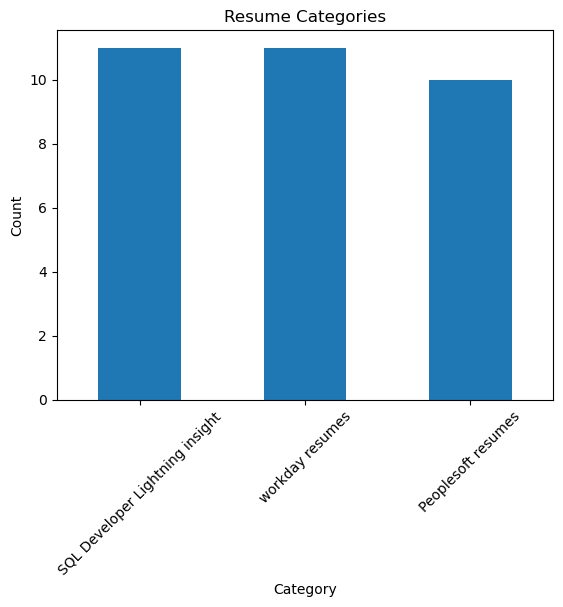

In [14]:

df["category"].value_counts().plot(kind='bar')
plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove special characters
    text = text.lower()                     # convert to lowercase
    text = text.split()                     # tokenize
    text = " ".join(text)                   # join back
    return text

In [16]:
df["cleaned"] = df["text"].apply(clean_text)
df.head()

,text,category,cleaned
0,Anubhav Kumar Singh\t\t To work in a global...,Peoplesoft resumes,anubhav kumar singh to work in a globally comp...
1,MuraliExperience Summary I have 6 years of exp...,Peoplesoft resumes,muraliexperience summary i have years of exper...
2,PROFILE SUMMARYI have overall 6.8 years’ exper...,Peoplesoft resumes,profile summaryi have overall years experience...
3,PeopleSoft AdminVARKALA VIKASCareer Objective...,Peoplesoft resumes,peoplesoft adminvarkala vikascareer objective ...
4,PeopleSoft Administration Vivekanand Sayana ...,Peoplesoft resumes,peoplesoft administration vivekanand sayana ca...


In [17]:
X = df["cleaned"]
y = df["category"]

In [18]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)
X = tfidf.fit_transform(X)

In [19]:

le = LabelEncoder()
y = le.fit_transform(y)

In [20]:
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [21]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [22]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC()
}

In [23]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

Naive Bayes Accuracy: 0.8571428571428571
Logistic Regression Accuracy: 0.8571428571428571
SVM Accuracy: 1.0


In [24]:
results

{'Naive Bayes': 0.8571428571428571,
 'Logistic Regression': 0.8571428571428571,
 'SVM': 1.0}

In [25]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: SVM


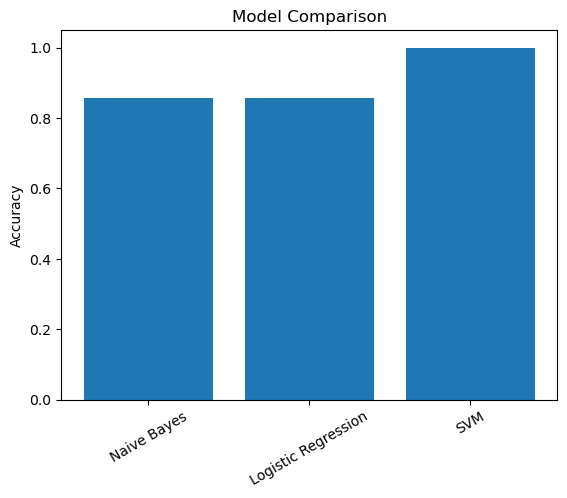

In [26]:
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [27]:
best_model = models[best_model_name]

import joblib
joblib.dump(best_model, "model.pkl")
joblib.dump(tfidf, "tfidf.pkl")

['tfidf.pkl']